In [1]:
import pandas as pd
import glob
import os

data_path = 'EEG_Data'
csv_pattern = os.path.join(data_path, '*.csv')

all_csv_files = glob.glob(csv_pattern)

if not all_csv_files:
    print(f"No CSV files found in the folder: {data_path}")
else:
    all_dataframes = []

    print(f"Found {len(all_csv_files)} CSV files to process:")
    
    for file_path in all_csv_files:
        print(f"Reading file: {file_path}")
        
        try:
            df = pd.read_csv(file_path)
            
            df['Source_File'] = os.path.basename(file_path)
            
            all_dataframes.append(df)
            
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    if all_dataframes:
        combined_df = pd.concat(all_dataframes, ignore_index=True)
        print("\nSuccessfully read all files.")
        print("First 5 rows of the combined DataFrame:")
        print(combined_df.head())
        print(f"Combined DataFrame shape: {combined_df.shape}")

Found 34 CSV files to process:
Reading file: EEG_Data\eeg_record10_EEG1.csv
Reading file: EEG_Data\eeg_record11_EEG1.csv
Reading file: EEG_Data\eeg_record12_EEG1.csv
Reading file: EEG_Data\eeg_record13_EEG1.csv
Reading file: EEG_Data\eeg_record14_EEG1.csv
Reading file: EEG_Data\eeg_record15_EEG1.csv
Reading file: EEG_Data\eeg_record16_EEG1.csv
Reading file: EEG_Data\eeg_record17_EEG1.csv
Reading file: EEG_Data\eeg_record18_EEG1.csv
Reading file: EEG_Data\eeg_record19_EEG1.csv
Reading file: EEG_Data\eeg_record1_EEG1.csv
Reading file: EEG_Data\eeg_record20_EEG1.csv
Reading file: EEG_Data\eeg_record21_EEG1.csv
Reading file: EEG_Data\eeg_record22_EEG1.csv
Reading file: EEG_Data\eeg_record23_EEG1.csv
Reading file: EEG_Data\eeg_record24_EEG1.csv
Reading file: EEG_Data\eeg_record25_EEG1.csv
Reading file: EEG_Data\eeg_record26_EEG1.csv
Reading file: EEG_Data\eeg_record27_EEG1.csv
Reading file: EEG_Data\eeg_record28_EEG1.csv
Reading file: EEG_Data\eeg_record29_EEG1.csv
Reading file: EEG_Data\ee

Loaded 34 files with selected channels (ch4–ch17).
Minimum usable length across all files: 214540
Ensemble averaging completed.
Averaged EEG Shape (samples, channels): (214540, 14)


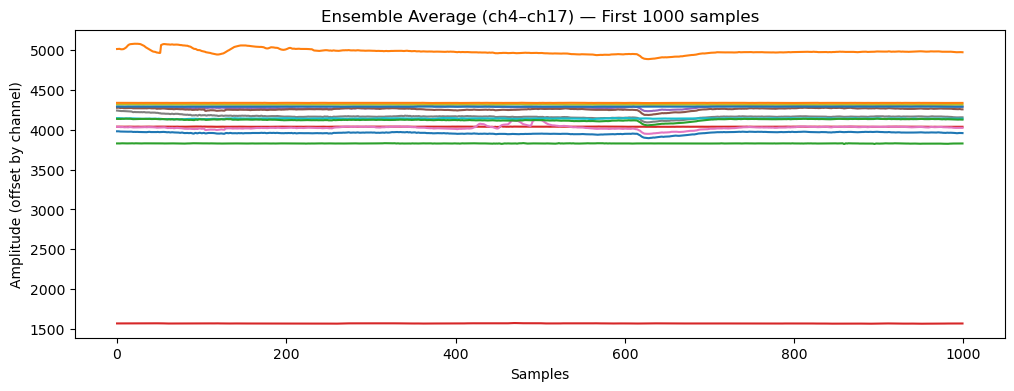

In [2]:
import numpy as np
import matplotlib.pyplot as plt

file_arrays = []
for df in all_dataframes:
    numeric_df = df.select_dtypes(include=[np.number])   # keep only numeric columns
    selected_array = numeric_df.iloc[:, 4:18].values     # ch4–ch17  -> 14 channels
    file_arrays.append(selected_array)

print(f"Loaded {len(file_arrays)} files with selected channels (ch4–ch17).")

# -----------------------------
#   ENSEMBLE AVERAGING
# -----------------------------

min_len = min(a.shape[0] for a in file_arrays)
print("Minimum usable length across all files:", min_len)

stacked = np.stack([a[:min_len, :] for a in file_arrays], axis=0)  # (n_files, min_len, 14)
ensemble_avg = np.mean(stacked, axis=0)                            # (min_len, 14)

print("Ensemble averaging completed.")
print("Averaged EEG Shape (samples, channels):", ensemble_avg.shape)

# -----------------------------
#   PREVIEW PLOT
# -----------------------------
plt.figure(figsize=(12,4))
for ch in range(14):     # plot all 14 channels
    plt.plot(ensemble_avg[:1000, ch] + ch*0.6)   # small offset for readability

plt.title("Ensemble Average (ch4–ch17) — First 1000 samples")
plt.xlabel("Samples")
plt.ylabel("Amplitude (offset by channel)")
plt.show()


Normalized EEG shape: (214540, 14)


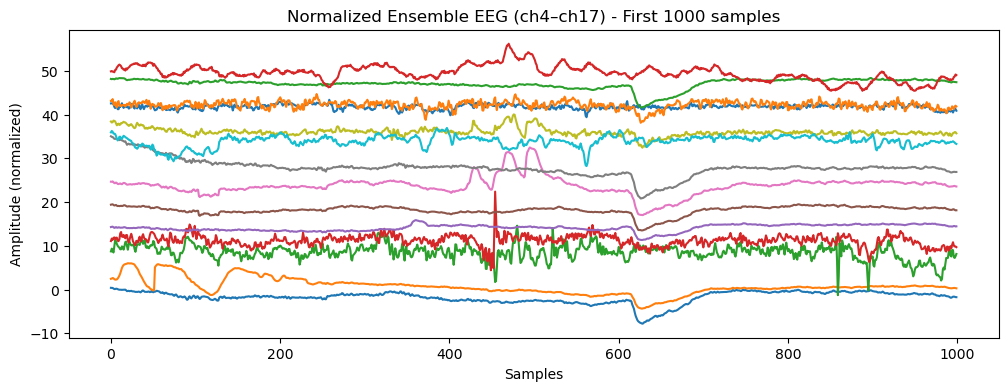

In [3]:
# Normalize the EEG Files

ensemble_norm = (ensemble_avg - np.mean(ensemble_avg, axis=0)) / np.std(ensemble_avg, axis=0)

print("Normalized EEG shape:", ensemble_norm.shape)

# Plot normalized data (first 1000 samples)
plt.figure(figsize=(12,4))
for ch in range(14):
    plt.plot(ensemble_norm[:1000, ch] + ch*4)  # spread out for clarity

plt.title("Normalized Ensemble EEG (ch4–ch17) - First 1000 samples")
plt.xlabel("Samples")
plt.ylabel("Amplitude (normalized)")
plt.show()


Savitzky–Golay smoothing - To remove High Frequency Noise

Applying Savitzky–Golay smoothing...
Smoothed EEG shape: (214540, 14)


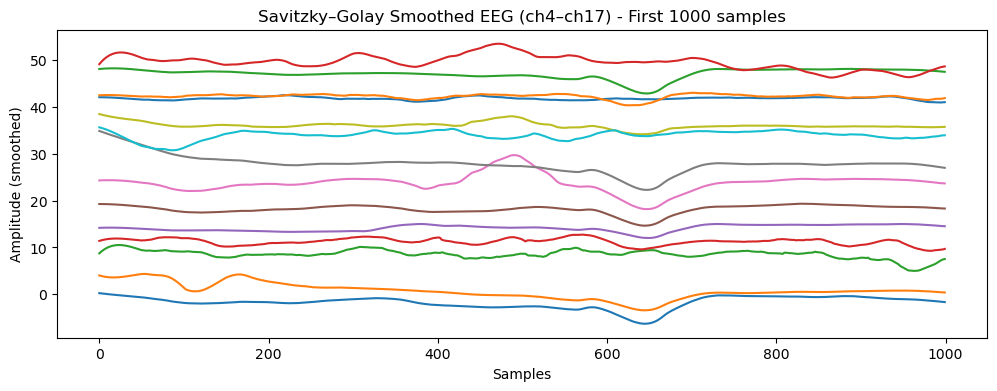

In [4]:
from scipy.signal import savgol_filter
import numpy as np
import matplotlib.pyplot as plt

def apply_savgol(signal_2d, window=101, poly=3):
    smoothed = np.zeros_like(signal_2d)
    for ch in range(signal_2d.shape[1]):
        smoothed[:, ch] = savgol_filter(signal_2d[:, ch], window_length=window, polyorder=poly)
    return smoothed

print("Applying Savitzky–Golay smoothing...")
smooth_signal = apply_savgol(ensemble_norm)

print("Smoothed EEG shape:", smooth_signal.shape)

plt.figure(figsize=(12,4))
for ch in range(14):
    plt.plot(smooth_signal[:1000, ch] + ch*4)
plt.title("Savitzky–Golay Smoothed EEG (ch4–ch17) - First 1000 samples")
plt.xlabel("Samples")
plt.ylabel("Amplitude (smoothed)")
plt.show()


Applying ICA artifact removal...
Detected artifact components: [9]
ICA Cleaned EEG shape: (214540, 14)


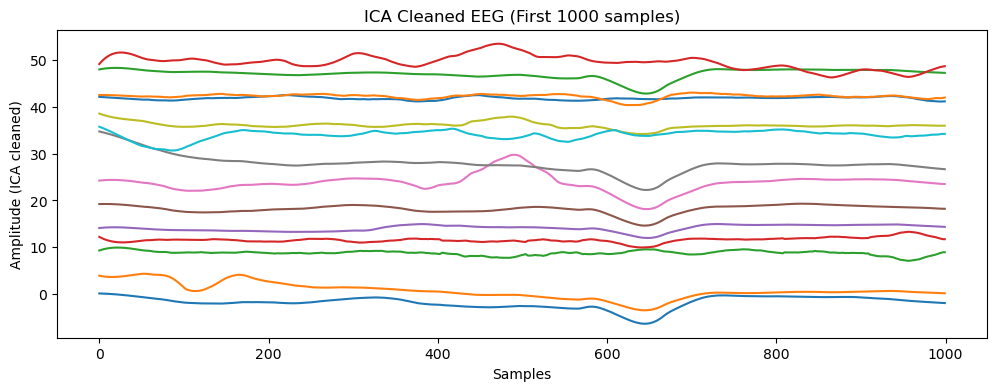

In [5]:
from sklearn.decomposition import FastICA
import numpy as np
import matplotlib.pyplot as plt

# ---------- ICA CLEANING ----------
print("Applying ICA artifact removal...")

ica = FastICA(n_components=14, random_state=42, max_iter=1000)

S = ica.fit_transform(smooth_signal)     # Independent components
A = ica.mixing_                          # Mixing matrix

kurt = np.abs(pd.DataFrame(S).kurtosis())
artifact_idx = kurt[kurt > (kurt.mean() + 2*kurt.std())].index.tolist()

print("Detected artifact components:", artifact_idx)

# Zero-out artifact ICs
S_clean = S.copy()
for idx in artifact_idx:
    S_clean[:, idx] = 0

ica_clean = np.dot(S_clean, A.T)

print("ICA Cleaned EEG shape:", ica_clean.shape)

# ---------- PLOT PREVIEW ----------
plt.figure(figsize=(12,4))
for ch in range(14):
    plt.plot(ica_clean[:1000, ch] + ch*4)
plt.title("ICA Cleaned EEG (First 1000 samples)")
plt.xlabel("Samples")
plt.ylabel("Amplitude (ICA cleaned)")
plt.show()


Epoch length: 256 samples
Step size: 128 samples
Total epochs created: 1675
Each epoch shape: (256, 14) (samples, channels)


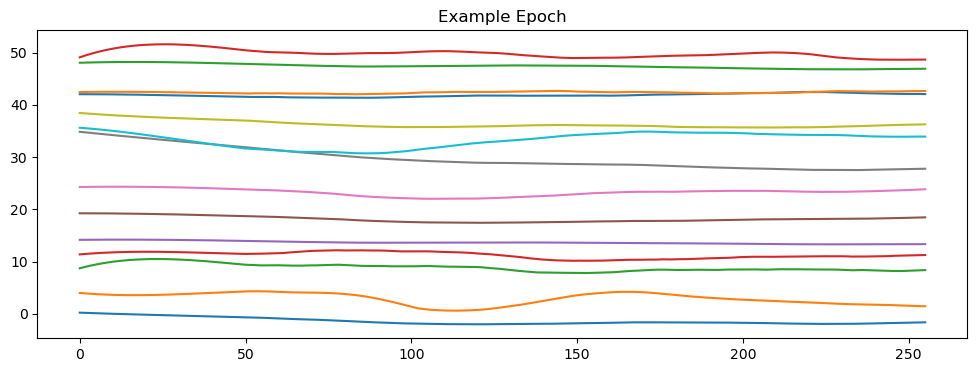

In [7]:
# --------- CONFIG ---------
sfreq = 128                      # sampling rate
epoch_duration = 2               # seconds
overlap = 0.5                    # 50%
epoch_length = int(epoch_duration * sfreq)
step = int(epoch_length * (1 - overlap))

print(f"Epoch length: {epoch_length} samples")
print(f"Step size: {step} samples")

# smoothed + normalized EEG from previous step
signal_data = smooth_signal      # shape: (samples, 14)

# --------- EPOCHING FUNCTION ---------
def create_epochs(data, epoch_len, step):
    epochs_list = []
    for start in range(0, len(data) - epoch_len + 1, step):
        epochs_list.append(data[start:start+epoch_len, :])
    return np.array(epochs_list)

# --------- CREATE EPOCHS ---------
epochs = create_epochs(signal_data, epoch_length, step)

print("Total epochs created:", epochs.shape[0])
print("Each epoch shape:", epochs.shape[1:], "(samples, channels)")

# --------- Plot one epoch -----------
plt.figure(figsize=(12,4))
for ch in range(14):
    plt.plot(epochs[0][:, ch] + ch*4)
plt.title("Example Epoch")
plt.show()


Epochs shape: (1675, 256, 14)
Computing DCT and keeping first 40 coefficients per channel...
DCT features shape (epochs x features): (1675, 560)
Saved: results\dct_features.npy


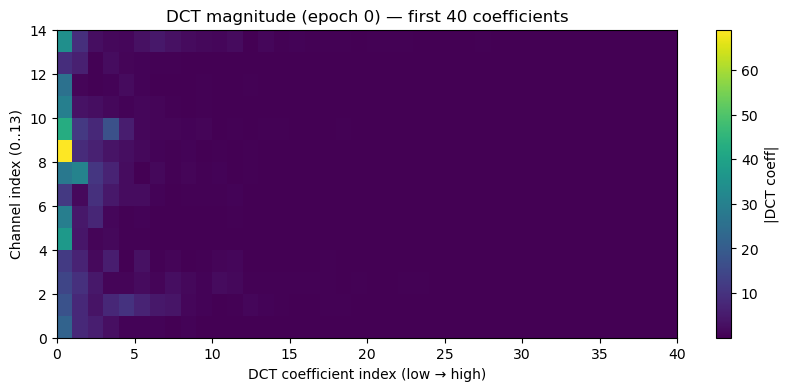

Saved DCT metadata.


In [8]:
# ---------------- I-DCT on epochs -> compact features ----------------
import numpy as np
from scipy.fftpack import dct
import matplotlib.pyplot as plt
from pathlib import Path

# Config
sfreq = 128                   # sampling rate you confirmed
n_channels = epochs.shape[2]  # should be 14
n_coef = 40                   # number of low-frequency DCT coefficients to keep per channel (tuneable)
OUT_PATH = Path("results")
OUT_PATH.mkdir(exist_ok=True)

print("Epochs shape:", epochs.shape)
print(f"Computing DCT and keeping first {n_coef} coefficients per channel...")

n_epochs, epoch_len, _ = epochs.shape
dct_coeffs = np.zeros((n_epochs, epoch_len, n_channels))

for i in range(n_epochs):
    dct_coeffs[i] = dct(epochs[i], axis=0, norm='ortho')  # shape (epoch_len, n_channels)

dct_low = dct_coeffs[:, :n_coef, :]  # (n_epochs, n_coef, n_channels)

dct_features = dct_low.reshape(n_epochs, n_coef * n_channels)  # shape (n_epochs, n_coef*n_channels)

print("DCT features shape (epochs x features):", dct_features.shape)

# Save features (numpy)
np.save(OUT_PATH / "dct_features.npy", dct_features)
print("Saved:", OUT_PATH / "dct_features.npy")

sample_idx = 0
plt.figure(figsize=(10,4))
plt.imshow(np.abs(dct_low[sample_idx].T), aspect='auto', origin='lower', extent=[0, n_coef, 0, n_channels])
plt.colorbar(label='|DCT coeff|')
plt.xlabel('DCT coefficient index (low → high)')
plt.ylabel('Channel index (0..{0})'.format(n_channels-1))
plt.title(f'DCT magnitude (epoch {sample_idx}) — first {n_coef} coefficients')
plt.show()

# store metadata
meta = {"sfreq": sfreq, "epoch_length": epoch_len, "n_coef": n_coef, "n_channels": n_channels}
import json
with open(OUT_PATH / "dct_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Saved DCT metadata.")


In [9]:
# ---------- Time-domain feature extraction per epoch & per channel ----------
from scipy import stats
from pathlib import Path

OUT = Path("results")
OUT.mkdir(exist_ok=True)

# sanity check
if 'epochs' not in globals():
    raise RuntimeError("Variable 'epochs' not found. Run the epoching cell first.")

n_epochs, epoch_len, n_channels = epochs.shape
print("Epochs shape:", epochs.shape)

def rms(x):
    return np.sqrt(np.mean(x**2))

def zero_cross_rate(x):
    s = np.sign(x)
    s[s==0] = 1  
    return np.sum(np.abs(np.diff(s)) > 0) / len(x)

def hjorth_parameters(x):
    var_x = np.var(x)
    dx = np.diff(x)
    var_dx = np.var(dx)
    ddx = np.diff(dx)
    var_ddx = np.var(ddx) if len(ddx)>0 else 0.0
    activity = var_x
    mobility = np.sqrt(var_dx / (var_x + 1e-12))
    complexity = np.sqrt((var_ddx / (var_dx + 1e-12)) - (mobility**2) + 1e-12)
    return activity, mobility, complexity

feat_names_per_channel = [
    "mean","var","rms","min","max","ptp",
    "skew","kurt",
    "zcr",
    "hj_activity","hj_mobility","hj_complexity"
]
n_feats_per_ch = len(feat_names_per_channel)
print(f"Computing {n_feats_per_ch} time-domain features per channel for {n_channels} channels.")

time_feats = np.zeros((n_epochs, n_channels * n_feats_per_ch), dtype=float)
col_names = []

for ch in range(n_channels):
    for fn in feat_names_per_channel:
        col_names.append(f"ch{ch}_{fn}")

# compute
for i in range(n_epochs):
    epoch = epochs[i]  # shape (epoch_len, n_channels)
    feat_row = []
    for ch in range(n_channels):
        x = epoch[:, ch].astype(float)
        m = np.mean(x)
        v = np.var(x)
        r = rms(x)
        mn = np.min(x)
        mx = np.max(x)
        p = mx - mn
        sk = float(stats.skew(x, bias=False))
        kur = float(stats.kurtosis(x, bias=False, fisher=False))  # Pearson (not Fisher)
        zcr = zero_cross_rate(x)
        haa, hmo, hco = hjorth_parameters(x)
        feat_row.extend([m, v, r, mn, mx, p, sk, kur, zcr, haa, hmo, hco])
    time_feats[i, :] = np.array(feat_row)

# Save
np.save(OUT / "time_features.npy", time_feats)
df_time = pd.DataFrame(time_feats, columns=col_names)
df_time.to_csv(OUT / "time_features.csv", index=False)

print("Saved time domain features:")
print(" -", OUT / "time_features.npy")
print(" -", OUT / "time_features.csv")
print("Time features matrix shape:", time_feats.shape)
display(df_time.head())


Epochs shape: (1675, 256, 14)
Computing 12 time-domain features per channel for 14 channels.


C:\Users\rnsma\AppData\Local\Temp\ipykernel_5468\4043794332.py:31: RuntimeWarning: invalid value encountered in sqrt
  complexity = np.sqrt((var_ddx / (var_dx + 1e-12)) - (mobility**2) + 1e-12)


Saved time domain features:
 - results\time_features.npy
 - results\time_features.csv
Time features matrix shape: (1675, 168)


,ch0_mean,ch0_var,ch0_rms,ch0_min,ch0_max,ch0_ptp,ch0_skew,ch0_kurt,ch0_zcr,ch0_hj_activity,...,ch13_rms,ch13_min,ch13_max,ch13_ptp,ch13_skew,ch13_kurt,ch13_zcr,ch13_hj_activity,ch13_hj_mobility,ch13_hj_complexity
0,-1.375548,0.422354,1.521344,-1.983354,0.237340,2.220694,1.105049,2.768806,0.003906,0.422354,...,2.284919,-3.353893,-0.400039,2.953854,0.599964,2.908731,0.000000,0.585884,0.063602,0.112587
1,-1.483874,0.131779,1.527632,-2.029639,-0.832451,1.197188,0.461501,1.764629,0.000000,0.131779,...,2.557985,-3.474120,-0.529062,2.945058,0.852341,2.786131,0.000000,0.659918,0.054255,0.142265
2,-1.886741,0.532389,2.022913,-2.804710,-0.832451,1.972260,0.125544,1.316042,0.000000,0.532389,...,1.919916,-3.474120,1.462487,4.936608,0.182421,1.910019,0.007812,2.189968,0.036419,0.120501
3,-3.075708,0.832941,3.208258,-6.199370,-2.056040,4.143329,-2.037636,6.420367,0.000000,0.832941,...,1.677004,-3.065777,1.462487,4.528264,0.514786,2.132893,0.007812,1.638070,0.036179,0.142263
4,-2.922286,3.401011,3.455542,-6.287725,-0.233494,6.054231,-0.139064,2.142020,0.000000,3.401011,...,2.364469,-4.180543,-0.878303,3.302240,-0.698593,3.264065,0.000000,0.628200,0.040161,0.199976


In [11]:
# ---------- PSD / Band-power feature extraction per epoch & channel ----------
from scipy.signal import welch
OUT = Path("results")
OUT.mkdir(exist_ok=True)

# sanity check
if 'epochs' not in globals():
    raise RuntimeError("Variable 'epochs' not found. Run the epoching cell first.")

sfreq = 128
n_epochs, epoch_len, n_channels = epochs.shape
print("Epochs shape:", epochs.shape)

# Define EEG bands (Hz)
bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta" : (13, 30),
    "gamma": (30, 50)
}

# helper: spectral entropy from power spectrum
def spectral_entropy(pxx):
    p = pxx / (np.sum(pxx) + 1e-12)
    ent = -np.sum(p * np.log(p + 1e-12))
    return ent

n_band = len(bands)
n_feats_per_ch = n_band + 1   # band powers + spectral entropy
total_features = n_channels * n_feats_per_ch

psd_feats = np.zeros((n_epochs, total_features), dtype=float)
col_names = []
for ch in range(n_channels):
    for band_name in list(bands.keys()):
        col_names.append(f"ch{ch}_bp_{band_name}")
    col_names.append(f"ch{ch}_spec_entropy")

# Compute PSD features epoch-by-epoch
for i in range(n_epochs):
    epoch = epochs[i]  # shape (epoch_len, n_channels)
    feat_row = []
    for ch in range(n_channels):
        sig = epoch[:, ch].astype(float)
        nperseg = min(256, len(sig))
        f, Pxx = welch(sig, fs=sfreq, nperseg=nperseg)
        total_power = np.trapz(Pxx, f) + 1e-12
        for (lo, hi) in bands.values():
            mask = (f >= lo) & (f <= hi)
            band_power = np.trapz(Pxx[mask], f[mask]) if np.any(mask) else 0.0
            feat_row.append(band_power / total_power)
        feat_row.append(spectral_entropy(Pxx))
    psd_feats[i, :] = np.array(feat_row)

np.save(OUT / "psd_band_features.npy", psd_feats)
df_psd = pd.DataFrame(psd_feats, columns=col_names)
df_psd.to_csv(OUT / "psd_band_features.csv", index=False)

print("Saved PSD band features:")
print(" -", OUT / "psd_band_features.npy")
print(" -", OUT / "psd_band_features.csv")
print("PSD features matrix shape:", psd_feats.shape)
display(df_psd.head())


Epochs shape: (1675, 256, 14)
Saved PSD band features:
 - results\psd_band_features.npy
 - results\psd_band_features.csv
PSD features matrix shape: (1675, 84)


,ch0_bp_delta,ch0_bp_theta,ch0_bp_alpha,ch0_bp_beta,ch0_bp_gamma,ch0_spec_entropy,ch1_bp_delta,ch1_bp_theta,ch1_bp_alpha,ch1_bp_beta,...,ch12_bp_alpha,ch12_bp_beta,ch12_bp_gamma,ch12_spec_entropy,ch13_bp_delta,ch13_bp_theta,ch13_bp_alpha,ch13_bp_beta,ch13_bp_gamma,ch13_spec_entropy
0,0.573548,0.000390,0.000041,3.119672e-05,2.805126e-06,1.105016,0.935106,0.000800,0.000055,1.373177e-05,...,0.000184,1.115767e-04,8.784494e-06,1.156040,0.760545,0.003259,0.000390,0.000020,1.885665e-06,1.421868
1,0.669128,0.000520,0.000050,3.266754e-05,5.064409e-06,0.781202,0.560180,0.000498,0.000049,5.638318e-06,...,0.000051,5.158782e-05,5.163216e-06,1.172930,0.886132,0.001070,0.000059,0.000017,9.167876e-07,1.217635
2,0.612652,0.000134,0.000019,1.084918e-05,1.271139e-06,0.647902,0.541977,0.000096,0.000017,6.874207e-06,...,0.000045,5.003741e-05,4.451037e-06,0.620477,0.692284,0.000912,0.000030,0.000006,3.554980e-07,1.057289
3,0.531699,0.002885,0.000139,1.935882e-05,1.737477e-06,1.338238,0.561988,0.000832,0.000033,3.900751e-06,...,0.000064,5.424888e-06,7.950643e-07,1.353443,0.636156,0.002492,0.000119,0.000005,4.234710e-07,1.254699
4,0.666008,0.000179,0.000006,3.397612e-07,7.031311e-08,1.204403,0.663025,0.000177,0.000005,2.040611e-07,...,0.000005,2.695509e-07,5.918398e-08,1.218702,0.885663,0.007733,0.001139,0.000023,5.836533e-06,1.196197


In [12]:
# ---------- Combine DCT + Time + PSD features into master X ----------
import numpy as np
import pandas as pd
from pathlib import Path
import json

OUT = Path("results")

# file paths
dct_fp = OUT / "dct_features.npy"
time_fp = OUT / "time_features.npy"
psd_fp = OUT / "psd_band_features.npy"

# -- check files exist
missing = [str(p.name) for p in (dct_fp, time_fp, psd_fp) if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing feature files in results/: {missing}. Run those cells first.")

# -- load arrays
dct = np.load(dct_fp)       
timef = np.load(time_fp)    
psd = np.load(psd_fp)       

print("Loaded shapes:")
print(" - DCT:", dct.shape)
print(" - Time:", timef.shape)
print(" - PSD :", psd.shape)

n_rows = dct.shape[0]
if not (timef.shape[0] == n_rows and psd.shape[0] == n_rows):
    raise ValueError(f"Epoch row mismatch: dct {dct.shape[0]}, time {timef.shape[0]}, psd {psd.shape[0]}. Ensure same epoching order and count.")

# -- Build column names
dct_meta_fp = OUT / "dct_meta.json"
if dct_meta_fp.exists():
    with open(dct_meta_fp, "r") as f:
        meta = json.load(f)
    n_coef = int(meta.get("n_coef", 40))
    n_channels = int(meta.get("n_channels", 14))
else:
    total_dct = dct.shape[1]
    n_channels = 14
    n_coef = total_dct // n_channels if total_dct % n_channels == 0 else total_dct // n_channels
    print("Warning: dct_meta.json missing, inferred n_coef =", n_coef, "n_channels =", n_channels)

dct_colnames = []
for ch in range(n_channels):
    for k in range(n_coef):
        dct_colnames.append(f"ch{ch}_dct_coef{k}")

time_csv = OUT / "time_features.csv"
if time_csv.exists():
    time_df_head = pd.read_csv(time_csv, nrows=0)
    time_colnames = list(time_df_head.columns)
else:
    feat_names_per_channel = [
        "mean","var","rms","min","max","ptp",
        "skew","kurt",
        "zcr",
        "hj_activity","hj_mobility","hj_complexity"
    ]
    time_colnames = []
    for ch in range(n_channels):
        for fn in feat_names_per_channel:
            time_colnames.append(f"ch{ch}_{fn}")

psd_csv = OUT / "psd_band_features.csv"
if psd_csv.exists():
    psd_colnames = list(pd.read_csv(psd_csv, nrows=0).columns)
else:
    # fallback: bands used earlier
    bands = ["delta","theta","alpha","beta","gamma"]
    psd_colnames = []
    for ch in range(n_channels):
        for b in bands:
            psd_colnames.append(f"ch{ch}_bp_{b}")
        psd_colnames.append(f"ch{ch}_spec_entropy")

# Validate lengths
if not (len(dct_colnames) == dct.shape[1]):
    print("Warning: DCT column name length mismatch. Using generic names.")
    dct_colnames = [f"dct_{i}" for i in range(dct.shape[1])]
if not (len(time_colnames) == timef.shape[1]):
    print("Warning: Time feature name count mismatch. Using generic names.")
    time_colnames = [f"time_{i}" for i in range(timef.shape[1])]
if not (len(psd_colnames) == psd.shape[1]):
    print("Warning: PSD feature name count mismatch. Using generic names.")
    psd_colnames = [f"psd_{i}" for i in range(psd.shape[1])]

# -- Concatenate horizontally
X_master = np.hstack([dct, timef, psd])
print("Concatenated X_master shape:", X_master.shape)

# -- Column names
feature_names = dct_colnames + time_colnames + psd_colnames
if len(feature_names) != X_master.shape[1]:
    # safety fallback
    feature_names = [f"f{i}" for i in range(X_master.shape[1])]
    print("Warning: feature_names length mismatch; using generic f0..fN names.")

# -- Save
np.save(OUT / "X_master.npy", X_master)
pd.DataFrame(X_master, columns=feature_names).to_csv(OUT / "X_master.csv", index=False)
with open(OUT / "feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

print("Saved master features:")
print(" -", OUT / "X_master.npy")
print(" -", OUT / "X_master.csv")
print(" -", OUT / "feature_names.json")

print("\nPreview shapes:")
print(" n_epochs:", n_rows)
print(" n_total_features:", X_master.shape[1])
print("\nFirst 5 columns names:", feature_names[:5])
display(pd.DataFrame(X_master[:5, :min(10, X_master.shape[1])], columns=feature_names[:min(10, X_master.shape[1])]))


Loaded shapes:
 - DCT: (1675, 560)
 - Time: (1675, 168)
 - PSD : (1675, 84)
Concatenated X_master shape: (1675, 812)
Saved master features:
 - results\X_master.npy
 - results\X_master.csv
 - results\feature_names.json

Preview shapes:
 n_epochs: 1675
 n_total_features: 812

First 5 columns names: ['ch0_dct_coef0', 'ch0_dct_coef1', 'ch0_dct_coef2', 'ch0_dct_coef3', 'ch0_dct_coef4']


,ch0_dct_coef0,ch0_dct_coef1,ch0_dct_coef2,ch0_dct_coef3,ch0_dct_coef4,ch0_dct_coef5,ch0_dct_coef6,ch0_dct_coef7,ch0_dct_coef8,ch0_dct_coef9
0,-22.008773,-17.440161,14.338184,-11.796304,-37.196404,-29.577422,-11.569698,27.586941,69.002460,-42.742999
1,-23.741977,-32.886854,11.628114,-12.470699,-36.471674,-27.728949,-4.256905,1.033607,64.391120,-27.602358
2,-30.187849,-54.353465,11.198456,-7.175789,-28.595578,-28.341745,19.116747,-2.188481,72.188226,-28.967280
3,-49.211331,-75.631831,9.492674,-8.904466,-31.326893,-37.693268,7.460613,-20.830731,66.965186,-32.645598
4,-46.756581,-82.983414,13.623321,-12.940332,-35.344976,-40.987839,-28.194451,-34.231538,55.230024,-29.830147


Continuing the Work, and reloading the data

In [1]:
import numpy as np
import json
from pathlib import Path

OUT = Path("results")
X_master = np.load(OUT / "X_master.npy")

with open(OUT / "feature_names.json", "r") as f:
    feature_names = json.load(f)

print("Loaded:", X_master.shape)


Loaded: (1675, 812)


In [2]:
# Notebook-friendly Criss-Cross run (drop-in replacement)
import numpy as np
import json
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.cluster import KMeans
import joblib, time

# CONFIG (tweak pop_size / iterations for faster runs)
CONFIG = {
    "data_dir": Path("results"),
    "pop_size": 20,
    "iterations": 30,
    "elite_frac": 0.2,
    "n_epochs": 20,
    "cv_folds": 3,
    "random_state": 42
}

OUT = CONFIG["data_dir"]
assert OUT.exists(), f"Results folder not found: {OUT.resolve()}"

def evaluate_features(mask, X, y, clf, cv=3):
    if mask.sum() == 0:
        return 0.0
    try:
        X_subset = X[:, mask == 1]
        n_splits = min(cv, max(2, len(np.unique(y))))
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
        scores = cross_val_score(clf, X_subset, y, cv=skf, scoring='accuracy', n_jobs=1)
        return float(scores.mean())
    except Exception:
        return 0.0

def create_individual(n_features, p_select=0.2):
    mask = (np.random.rand(n_features) < p_select).astype(int)
    if mask.sum() == 0:
        mask[np.random.randint(n_features)] = 1
    return mask

def crossover(parent1, parent2):
    selector = np.random.rand(len(parent1)) < 0.5
    return np.where(selector, parent1, parent2).astype(int)

def mutate(individual, prob=0.25, frac=0.01):
    if np.random.rand() >= prob:
        return individual
    n = len(individual)
    n_mutate = max(1, int(np.ceil(frac * n)))
    indices = np.random.choice(n, n_mutate, replace=False)
    individual[indices] = 1 - individual[indices]
    if individual.sum() == 0:
        individual[np.random.randint(n)] = 1
    return individual

def cco_optimize(X, y, config):
    np.random.seed(config["random_state"])
    clf = RandomForestClassifier(n_estimators=200, random_state=config["random_state"])
    n_features = X.shape[1]
    pop_size = config["pop_size"]
    population = np.array([create_individual(n_features) for _ in range(pop_size)])
    best_mask, best_score = None, -1.0
    history = {"scores": [], "counts": []}
    start_time = time.time()
    for iteration in range(config["iterations"]):
        scores = np.array([evaluate_features(ind, X, y, clf, config["cv_folds"]) for ind in population])
        best_idx = scores.argmax()
        if scores[best_idx] > best_score:
            best_score = scores[best_idx]
            best_mask = population[best_idx].copy()
            print(f"[{iteration+1}/{config['iterations']}] Score: {best_score:.4f}, Features: {best_mask.sum()}")
        history["scores"].append(float(best_score))
        history["counts"].append(int(best_mask.sum()) if best_mask is not None else 0)
        # selection & reproduction
        n_elite = max(1, int(config["elite_frac"] * pop_size))
        elite_indices = scores.argsort()[-n_elite:]
        new_population = [population[i].copy() for i in elite_indices]
        while len(new_population) < pop_size:
            parents = np.random.choice(len(population), 2, replace=False)
            child = crossover(population[parents[0]], population[parents[1]])
            child = mutate(child)
            new_population.append(child)
        population = np.array(new_population)
    duration = time.time() - start_time
    print(f"CCO finished in {duration:.1f}s. Best score: {best_score:.4f}. Selected features: {int(best_mask.sum())}")
    return best_mask, best_score, history

def load_data(data_dir, n_epochs):
    X_all = np.load(data_dir / "X_master.npy")
    X = X_all[:n_epochs]
    feat_file = data_dir / "feature_names.json"
    if feat_file.exists():
        with open(feat_file) as f:
            feature_names = json.load(f)
    else:
        feature_names = [f"feature_{i}" for i in range(X.shape[1])]
    label_file = data_dir / "labels.npy"
    if label_file.exists():
        y = np.load(label_file)[:n_epochs]
    else:
        print("Creating surrogate labels via KMeans...")
        y = KMeans(n_clusters=2, random_state=CONFIG["random_state"], n_init=10).fit_predict(X)
    return X, y, feature_names

def save_results(mask, score, history, feature_names, output_dir):
    selected_idx = np.where(mask == 1)[0].tolist()
    selected_names = [feature_names[i] for i in selected_idx]
    results = {
        "n_features_selected": len(selected_idx),
        "selected_indices": selected_idx,
        "selected_names": selected_names,
        "best_score": float(score),
        "history": history
    }
    output_file = output_dir / "selected_features_cco.json"
    with open(output_file, "w") as f:
        json.dump(results, f, indent=2)
    joblib.dump(results, output_dir / "selected_features_cco.joblib")
    print(f"\nResults saved to {output_file}")
    print(f"Selected {len(selected_idx)} features (score: {score:.4f})")
    return results

# MAIN
print("Loading data...")
X, y, feature_names = load_data(CONFIG["data_dir"], CONFIG["n_epochs"])
print(f"Data shape: {X.shape}, Labels classes: {np.unique(y).tolist()}")
print("\nRunning CCO optimization...")
mask, score, history = cco_optimize(X, y, CONFIG)
results = save_results(mask, score, history, feature_names, CONFIG["data_dir"])

# expose to notebook namespace
mask_cco = mask
selected_feature_indices = results["selected_indices"]
selected_feature_names = results["selected_names"]


Loading data...
Creating surrogate labels via KMeans...
Data shape: (20, 812), Labels classes: [0, 1]

Running CCO optimization...


C:\Users\rnsma\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
C:\Users\rnsma\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
C:\Users\rnsma\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
C:\Users\rnsma\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
C:\Users\rnsma\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
C:\Users\rnsma\anaconda3\Lib\s

[1/30] Score: 0.9500, Features: 181


C:\Users\rnsma\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
C:\Users\rnsma\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
C:\Users\rnsma\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
C:\Users\rnsma\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
C:\Users\rnsma\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
C:\Users\rnsma\anaconda3\Lib\s

CCO finished in 617.0s. Best score: 0.9500. Selected features: 181

Results saved to results\selected_features_cco.json
Selected 181 features (score: 0.9500)


In [4]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
    --------------------------------------- 1.6/72.0 MB 7.6 MB/s eta 0:00:10
   - -------------------------------------- 3.1/72.0 MB 7.4 MB/s eta 0:00:10
   -- ------------------------------------- 4.7/72.0 MB 7.3 MB/s eta 0:00:10
   --- ------------------------------------ 6.3/72.0 MB 7.4 MB/s eta 0:00:09
   ---- ----------------------------------- 7.9/72.0 MB 7.4 MB/s eta 0:00:09
   ----- ---------------------------------- 9.4/72.0 MB 7.3 MB/s eta 0:00:09
   ------ --------------------------------- 11.0/72.0 MB 7.3 MB/s eta 0:00:09
   ------ --------------------------------- 12.6/72.0 MB 7.4 MB/s eta 0:00:09
   ------- -------------------------------- 14.2/72.0 MB 7.3 MB/s eta 0:00:08
   -------- ------------------------------- 16.0/72.0 MB 7.3 MB/s eta 0:00:08
   --------- ------------------------------ 17.3/72.0 MB 7.4 MB/s eta 0:00:08
   ---------- ----------------------------- 18.9/72.0 MB 7.4 MB/s eta 0:00:08

In [5]:
# ---------------- Apply CCO mask -> Train & Test selected features ----------------
import numpy as np
import json
from pathlib import Path
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, matthews_corrcoef
from sklearn.cluster import KMeans

OUT = Path("results")
assert (OUT / "X_master.npy").exists(), "results/X_master.npy missing."

# 1) Load X_master and CCO selection
X = np.load(OUT / "X_master.npy")
feat_names = (json.load(open(OUT / "feature_names.json")) if (OUT / "feature_names.json").exists() else [f"f{i}" for i in range(X.shape[1])])

sel_fp = OUT / "selected_features_cco.json"
if not sel_fp.exists():
    raise FileNotFoundError("No selected_features_cco.json found — run CCO first.")
sel = json.load(open(sel_fp))
sel_idxs = sel.get("selected_indices", [])
if len(sel_idxs) == 0:
    raise RuntimeError("CCO selection empty. Re-run CCO or use X_master full set.")

X_sel = X[:, sel_idxs]
sel_feat_names = [feat_names[i] for i in sel_idxs]
print("X_master shape:", X.shape)
print("Reduced X shape (selected features):", X_sel.shape)

# 2) Load labels y (prefer results/labels.npy or notebook var 'y'); else KMeans surrogate
y = None
if 'y' in globals() and hasattr(globals()['y'], "__len__") and len(globals()['y']) >= X_sel.shape[0]:
    y = np.array(globals()['y'])[:X_sel.shape[0]]
    print("Using 'y' from notebook environment.")
else:
    labels_fp = OUT / "labels.npy"
    if labels_fp.exists():
        y_try = np.load(labels_fp)
        if len(y_try) >= X_sel.shape[0]:
            y = y_try[:X_sel.shape[0]]
            print("Loaded labels from results/labels.npy")
if y is None:
    print("WARNING: No ground-truth labels found; creating SURROGATE labels via KMeans (demo only).")
    y = KMeans(n_clusters=2, random_state=42, n_init=10).fit_predict(X_sel)
    print("Surrogate label distribution:", dict(zip(*np.unique(y, return_counts=True))))

# 3) Determine grouping (subject-wise) if available
groups = None
subjects_fp = OUT / "subjects.npy"
if subjects_fp.exists():
    groups = np.load(subjects_fp)
    if len(groups) >= X_sel.shape[0]:
        groups = groups[:X_sel.shape[0]]
        print("Using subject-wise grouping from results/subjects.npy")
    else:
        groups = None

# 4) Train/test split
test_size = 0.3
if groups is not None:
    # do subject-wise holdout: choose unique subjects for test set
    unique_subj = np.unique(groups)
    # stratify by label per-subject: compute majority label per subject
    subj_labels = {s: np.bincount(y[groups==s]).argmax() for s in unique_subj}
    subj_list = np.array(list(unique_subj))
    subj_labels_arr = np.array([subj_labels[s] for s in subj_list])
    s_train, s_test = train_test_split(subj_list, test_size=test_size, stratify=subj_labels_arr, random_state=42)
    test_mask = np.isin(groups, s_test)
    train_mask = ~test_mask
    X_train, X_test = X_sel[train_mask], X_sel[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    print(f"Subject-wise split -> train subjects: {len(s_train)}, test subjects: {len(s_test)}")
else:
    X_train, X_test, y_train, y_test = train_test_split(X_sel, y, test_size=test_size, stratify=y, random_state=42)
    print(f"Stratified split -> train: {len(y_train)}, test: {len(y_test)}")

# 5) Models to train
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

def evaluate_model(name, clf, Xtr, ytr, Xte, yte):
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    # CV on train
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    try:
        cv_acc = float(np.mean(cross_val_score(pipe, Xtr, ytr, cv=cv, scoring='accuracy', n_jobs=4)))
    except Exception:
        cv_acc = None
    # fit and predict on test
    pipe.fit(Xtr, ytr)
    ypred = pipe.predict(Xte)
    try:
        yscore = pipe.predict_proba(Xte)[:,1]
    except Exception:
        try:
            yscore = pipe.decision_function(Xte)
        except Exception:
            yscore = None
    metrics = {
        "cv_accuracy": cv_acc,
        "test_accuracy": float(accuracy_score(yte, ypred)),
        "precision": float(precision_score(yte, ypred, zero_division=0)),
        "recall": float(recall_score(yte, ypred, zero_division=0)),
        "f1": float(f1_score(yte, ypred, zero_division=0)),
        "mcc": float(matthews_corrcoef(yte, ypred))
    }
    if yscore is not None and len(np.unique(yte)) == 2:
        try:
            metrics["roc_auc"] = float(roc_auc_score(yte, yscore))
        except Exception:
            metrics["roc_auc"] = None
    else:
        metrics["roc_auc"] = None
    cm = confusion_matrix(yte, ypred).tolist()
    return pipe, metrics, cm

# 6) Train & evaluate all models, keep best by test_accuracy
results = {}
best_model = None
best_score = -1.0

for name, clf in models.items():
    print(f"\nTraining {name} ...")
    pipe, metrics, cm = evaluate_model(name, clf, X_train, y_train, X_test, y_test)
    results[name] = {"metrics": metrics, "confusion_matrix": cm}
    print("Metrics:", metrics)
    print("Confusion matrix:", cm)
    if metrics["test_accuracy"] > best_score:
        best_score = metrics["test_accuracy"]
        best_model = (name, pipe, metrics)

# 7) Save results
joblib.dump(results, OUT / "training_results.joblib")
if best_model is not None:
    best_name, best_pipe, best_metrics = best_model
    joblib.dump(best_pipe, OUT / "best_model.joblib")
    print(f"\nBest model: {best_name} (test_accuracy={best_metrics['test_accuracy']:.4f}) saved to results/best_model.joblib")

# 8) Summary table
df_summary = pd.DataFrame([{ "model": name, **res["metrics"] } for name,res in results.items()])
display(df_summary)

# 9) Simple feature-type importance aggregation (if names have dct/time/psd tokens)
imp_info = {}
# only compute importances for tree model if available
if "RandomForest" in results:
    rf_pipe = joblib.load(OUT / "best_model.joblib") if best_model and best_name=="RandomForest" else None
    # try to get feature importances from the RandomForest trained above
    try:
        rf = results["RandomForest"].get("model_obj", None)  # not saved here; we can refit quickly
    except Exception:
        rf = None

# quick aggregate by token
type_counts = {"dct":0,"time":0,"psd":0,"other":0}
for nm in sel_feat_names:
    lnm = nm.lower()
    if "dct" in lnm:
        type_counts["dct"] += 1
    elif any(t in lnm for t in ["hj_","mean","var","rms","skew","kurt","zcr"]):
        type_counts["time"] += 1
    elif "bp_" in lnm or "spec_entropy" in lnm:
        type_counts["psd"] += 1
    else:
        type_counts["other"] += 1

print("\nSelected-feature composition by type (approx):", type_counts)

# Save final selected X and names
np.save(OUT / "X_selected.npy", X_sel)
with open(OUT / "selected_feature_names.txt","w") as f:
    f.write("\n".join(sel_feat_names))

print("\nSaved X_selected.npy and selected_feature_names.txt")
print("Training complete.")


X_master shape: (1675, 812)
Reduced X shape (selected features): (1675, 181)
Surrogate label distribution: {0: 404, 1: 1271}
Stratified split -> train: 1172, test: 503

Training LogisticRegression ...
Metrics: {'cv_accuracy': 0.9547663211492999, 'test_accuracy': 0.9602385685884692, 'precision': 0.9738219895287958, 'recall': 0.9738219895287958, 'f1': 0.9738219895287958, 'mcc': 0.8911773614296222, 'roc_auc': 0.9911081303275496}
Confusion matrix: [[111, 10], [10, 372]]

Training SVM ...
Metrics: {'cv_accuracy': 0.9180469176213857, 'test_accuracy': 0.9343936381709742, 'precision': 0.9245742092457421, 'recall': 0.9947643979057592, 'f1': 0.9583858764186634, 'mcc': 0.8165802708121238, 'roc_auc': 0.9832547271861884}
Confusion matrix: [[90, 31], [2, 380]]

Training RandomForest ...
Metrics: {'cv_accuracy': 0.9445426441171122, 'test_accuracy': 0.9423459244532804, 'precision': 0.9560723514211886, 'recall': 0.9685863874345549, 'f1': 0.9622886866059818, 'mcc': 0.8402677631621125, 'roc_auc': 0.98259

C:\Users\rnsma\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:31:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Metrics: {'cv_accuracy': 0.9539370794689944, 'test_accuracy': 0.9582504970178927, 'precision': 0.973753280839895, 'recall': 0.9712041884816754, 'f1': 0.9724770642201835, 'mcc': 0.8860709684940528, 'roc_auc': 0.9917139024706849}
Confusion matrix: [[111, 10], [11, 371]]

Best model: LogisticRegression (test_accuracy=0.9602) saved to results/best_model.joblib


,model,cv_accuracy,test_accuracy,precision,recall,f1,mcc,roc_auc
0,LogisticRegression,0.954766,0.960239,0.973822,0.973822,0.973822,0.891177,0.991108
1,SVM,0.918047,0.934394,0.924574,0.994764,0.958386,0.816580,0.983255
2,RandomForest,0.944543,0.942346,0.956072,0.968586,0.962289,0.840268,0.982595
3,XGBoost,0.953937,0.958250,0.973753,0.971204,0.972477,0.886071,0.991714



Selected-feature composition by type (approx): {'dct': 123, 'time': 34, 'psd': 14, 'other': 10}

Saved X_selected.npy and selected_feature_names.txt
Training complete.


Saved grid PNG -> results\confusion_matrices_grid.png
Saved: results\cm_RandomForest.png
Saved: results\cm_SVM.png
Saved: results\cm_LogisticRegression.png
Saved: results\cm_XGBoost.png


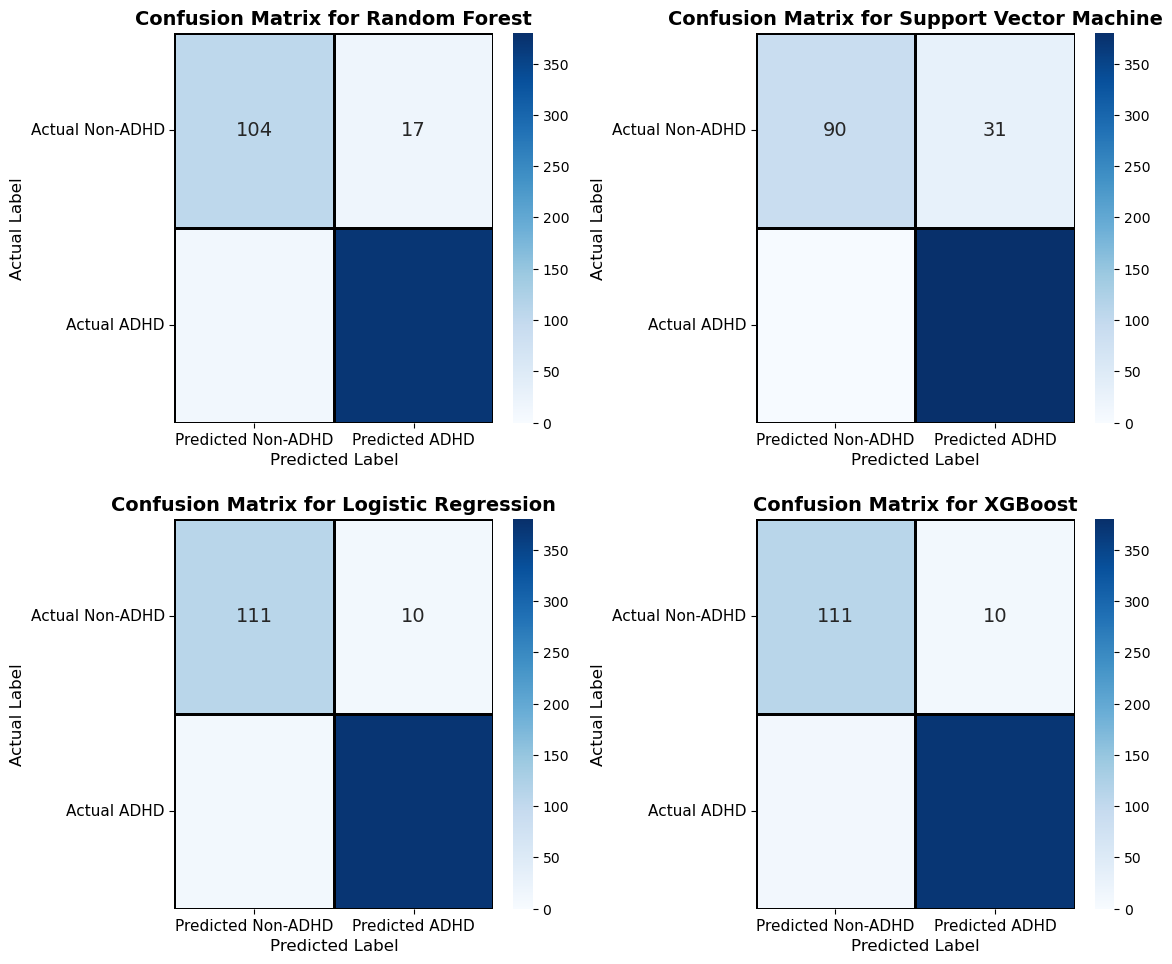

In [7]:
# Pretty confusion matrices with exact labels + save PNGs (PPT-ready)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

OUT = Path("results")
res = joblib.load(OUT / "training_results.joblib")

# order you want displayed (change if needed)
model_order = ["RandomForest", "SVM", "LogisticRegression", "XGBoost"]

# readable model titles mapping (optional)
title_map = {
    "RandomForest": "Random Forest",
    "SVM": "Support Vector Machine",
    "LogisticRegression": "Logistic Regression",
    "XGBoost": "XGBoost"
}

class_names = ["Non-ADHD", "ADHD"]   # IMPORTANT: index 0 -> Non-ADHD, index 1 -> ADHD

# determine global vmax for consistent color scale
cm_values = []
for m in model_order:
    if m in res:
        cm_values.append(np.array(res[m]["confusion_matrix"]))
if len(cm_values) == 0:
    raise RuntimeError("No confusion matrices found in results/training_results.joblib")
vmax = max(cm.max() for cm in cm_values)

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, model_key in zip(axes, model_order):
    if model_key not in res:
        ax.axis("off")
        continue
    cm = np.array(res[model_key]["confusion_matrix"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        ax=ax,
        vmin=0,
        vmax=vmax,
        annot_kws={"size": 14},
        linewidths=0.8,
        linecolor="black"
    )
    ax.set_title(f"Confusion Matrix for {title_map.get(model_key, model_key)}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("Actual Label", fontsize=12)
    # set tick labels exactly as requested
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels([f"Predicted {class_names[0]}", f"Predicted {class_names[1]}"], rotation=0, fontsize=11)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels([f"Actual {class_names[0]}", f"Actual {class_names[1]}"], rotation=0, va="center", fontsize=11)

plt.tight_layout(pad=2.0)
out_png = OUT / "confusion_matrices_grid.png"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
print("Saved grid PNG ->", out_png)

# Also save individual PNGs (one file per model) for slide placement
for model_key in model_order:
    if model_key not in res:
        continue
    cm = np.array(res[model_key]["confusion_matrix"])
    fig2, ax2 = plt.subplots(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True,
        ax=ax2,
        vmin=0,
        vmax=vmax,
        annot_kws={"size": 14},
        linewidths=0.8,
        linecolor="black"
    )
    ax2.set_title(f"Confusion Matrix for {title_map.get(model_key, model_key)}", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Predicted Label", fontsize=11)
    ax2.set_ylabel("Actual Label", fontsize=11)
    ax2.set_xticks([0.5, 1.5])
    ax2.set_xticklabels([f"Predicted {class_names[0]}", f"Predicted {class_names[1]}"], rotation=0, fontsize=10)
    ax2.set_yticks([0.5, 1.5])
    ax2.set_yticklabels([f"Actual {class_names[0]}", f"Actual {class_names[1]}"], rotation=0, va="center", fontsize=10)
    fname = OUT / f"cm_{model_key}.png"
    fig2.savefig(fname, dpi=300, bbox_inches="tight")
    plt.close(fig2)
    print("Saved:", fname)

plt.show()


Applying XAI

In [2]:
import numpy as np
import json
import joblib
from pathlib import Path
OUT = Path("results")

# Load selected features
sel = json.load(open(OUT / "selected_features_cco.json"))
selected_idxs = sel["selected_indices"]
selected_features_names = sel["selected_names"]

# Loading X_master
X_master = np.load(OUT /"X_master.npy")
X_sel = X_master[:,selected_idxs]

# load labels
labels_fp =OUT / "labels.npy"
if labels_fp.exists():
    y = np.load(labels_fp)
else:
    y = None
print("X_sel shape",X_sel.shape)
print("Selected feature count:",len(selected_idxs))
print("Best model ready at result/best_model.joblib")

X_sel shape (1675, 181)
Selected feature count: 181
Best model ready at result/best_model.joblib


In [3]:
!pip install shap


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Inspect EEG files and compute epochs per file
from pathlib import Path
import pandas as pd, json
import math

DATA_DIR = Path("EEG_Data")
OUT = Path("results"); OUT.mkdir(exist_ok=True)

EPOCH_LEN = 256   # change here if your epoch length is different
files = sorted(DATA_DIR.glob("*.csv"))

file_info = []
total_epochs = 0

print(f"Found {len(files)} CSV files in {DATA_DIR.resolve()}\n")
for p in files:
    try:
        # only count rows (fast)
        n_rows = sum(1 for _ in open(p, 'r', errors='ignore')) - 1  # subtract header row if present
        # if header absence causes negative, fallback to pandas
        if n_rows <= 0:
            import pandas as pd
            df = pd.read_csv(p)
            n_rows = df.shape[0]
    except Exception:
        # fallback
        import pandas as pd
        df = pd.read_csv(p)
        n_rows = df.shape[0]

    n_epochs = n_rows // EPOCH_LEN
    total_epochs += n_epochs
    file_info.append({"file": p.name, "n_samples": int(n_rows), "n_epochs": int(n_epochs)})
    print(f"{p.name:40s}  samples: {n_rows:6d}   epochs (floor): {n_epochs}")

print("\nTotal epochs (sum over files, floor division):", total_epochs)
# Save file_order for later
json.dump(file_info, open(OUT / "file_order.json", "w"), indent=2)
print("Saved file_order.json ->", OUT / "file_order.json")


Found 34 CSV files in C:\Users\rnsma\Final_Year_Project_2\EEG_Data

eeg_record10_EEG1.csv                     samples: 381340   epochs (floor): 1489
eeg_record11_EEG1.csv                     samples: 391624   epochs (floor): 1529
eeg_record12_EEG1.csv                     samples: 356728   epochs (floor): 1393
eeg_record13_EEG1.csv                     samples: 373304   epochs (floor): 1458
eeg_record14_EEG1.csv                     samples: 345164   epochs (floor): 1348
eeg_record15_EEG1.csv                     samples: 359164   epochs (floor): 1402
eeg_record16_EEG1.csv                     samples: 234372   epochs (floor): 915
eeg_record17_EEG1.csv                     samples: 443972   epochs (floor): 1734
eeg_record18_EEG1.csv                     samples: 361840   epochs (floor): 1413
eeg_record19_EEG1.csv                     samples: 333236   epochs (floor): 1301
eeg_record1_EEG1.csv                      samples: 308868   epochs (floor): 1206
eeg_record20_EEG1.csv                     

In [5]:
# Create a mapping template (JSON + printed Python skeleton) for manual editing
import json
from pathlib import Path

OUT = Path("results")
OUT.mkdir(exist_ok=True)

# Load file order
file_order = json.load(open(OUT / "file_order.json"))
files = [entry['file'] for entry in file_order]

# Default placeholder labels (0), you will change values manually
template = {f: 0 for f in files}

# Save JSON template
tpl_fp = OUT / "labels_mapping_template.json"
with open(tpl_fp, "w") as f:
    json.dump(template, f, indent=2)

print("📄 Template saved at:", tpl_fp)
print("\n📌 COPY THIS SKELETON, edit each file's label (0 = Non-ADHD, 1 = ADHD), then paste it back into your mapping cell:\n")
print("mapping = {")
for f in files:
    print(f'    "{f}": 0,')
print("}")


📄 Template saved at: results\labels_mapping_template.json

📌 COPY THIS SKELETON, edit each file's label (0 = Non-ADHD, 1 = ADHD), then paste it back into your mapping cell:

mapping = {
    "eeg_record10_EEG1.csv": 0,
    "eeg_record11_EEG1.csv": 0,
    "eeg_record12_EEG1.csv": 0,
    "eeg_record13_EEG1.csv": 0,
    "eeg_record14_EEG1.csv": 0,
    "eeg_record15_EEG1.csv": 0,
    "eeg_record16_EEG1.csv": 0,
    "eeg_record17_EEG1.csv": 0,
    "eeg_record18_EEG1.csv": 0,
    "eeg_record19_EEG1.csv": 0,
    "eeg_record1_EEG1.csv": 0,
    "eeg_record20_EEG1.csv": 0,
    "eeg_record21_EEG1.csv": 0,
    "eeg_record22_EEG1.csv": 0,
    "eeg_record23_EEG1.csv": 0,
    "eeg_record24_EEG1.csv": 0,
    "eeg_record25_EEG1.csv": 0,
    "eeg_record26_EEG1.csv": 0,
    "eeg_record27_EEG1.csv": 0,
    "eeg_record28_EEG1.csv": 0,
    "eeg_record29_EEG1.csv": 0,
    "eeg_record2_EEG1.csv": 0,
    "eeg_record30_EEG1.csv": 0,
    "eeg_record31_EEG1.csv": 0,
    "eeg_record32_EEG1.csv": 0,
    "eeg_record3

In [6]:
# ===== ADHD / Non-ADHD manual mapping (Option 1) =====

mapping = {
    "eeg_record1_EEG1.csv": 0,
    "eeg_record2_EEG1.csv": 0,
    "eeg_record3_EEG1.csv": 0,
    "eeg_record4_EEG1.csv": 1,   # ADHD
    "eeg_record5_EEG1.csv": 0,
    "eeg_record6_EEG1.csv": 0,
    "eeg_record7_EEG1.csv": 0,
    "eeg_record8_EEG1.csv": 1,   # ADHD
    "eeg_record9_EEG1.csv": 1,   # ADHD
    "eeg_record10_EEG1.csv": 0,
    "eeg_record11_EEG1.csv": 0,
    "eeg_record12_EEG1.csv": 0,
    "eeg_record13_EEG1.csv": 0,
    "eeg_record14_EEG1.csv": 1,  # ADHD
    "eeg_record15_EEG1.csv": 0,
    "eeg_record16_EEG1.csv": 0,
    "eeg_record17_EEG1.csv": 1,  # ADHD
    "eeg_record18_EEG1.csv": 0,
    "eeg_record19_EEG1.csv": 0,
    "eeg_record20_EEG1.csv": 1,  # ADHD
    "eeg_record21_EEG1.csv": 0,
    "eeg_record22_EEG1.csv": 0,
    "eeg_record23_EEG1.csv": 1,  # ADHD
    "eeg_record24_EEG1.csv": 0,
    "eeg_record25_EEG1.csv": 0,
    "eeg_record26_EEG1.csv": 1,  # ADHD
    "eeg_record27_EEG1.csv": 0,
    "eeg_record28_EEG1.csv": 0,
    "eeg_record29_EEG1.csv": 0,
    "eeg_record30_EEG1.csv": 0,
    "eeg_record31_EEG1.csv": 1,  # ADHD
    "eeg_record32_EEG1.csv": 0,
    "eeg_record33_EEG1.csv": 1,  # ADHD
    "eeg_record34_EEG1.csv": 0
}


In [7]:
# === Create labels.npy from manual mapping ===
import numpy as np
import json
from pathlib import Path

OUT = Path("results")
file_order = json.load(open(OUT / "file_order.json"))

# mapping dictionary must already be defined above

# Validation
files_in_order = [entry['file'] for entry in file_order]
missing = [f for f in files_in_order if f not in mapping]
if missing:
    raise KeyError(f"The following files are missing in mapping: {missing}")

# Expand to epoch-level labels
labels = []
for entry in file_order:
    fname = entry['file']
    n_ep = int(entry['n_epochs'])
    lab = int(mapping[fname])
    labels += [lab] * n_ep

labels = np.array(labels, dtype=int)
np.save(OUT / "labels.npy", labels)

print("Saved results/labels.npy  --> shape:", labels.shape)
print("Label distribution:", dict(zip(*np.unique(labels, return_counts=True))))


Saved results/labels.npy  --> shape: (48858,)
Label distribution: {0: 33298, 1: 15560}


In [8]:
# Verify alignment between label count and feature rows
import numpy as np
from pathlib import Path
OUT = Path("results")

labels = np.load(OUT / "labels.npy")

if (OUT / "X_selected.npy").exists():
    X = np.load(OUT / "X_selected.npy")
    print("Using X_selected.npy")
else:
    X = np.load(OUT / "X_master.npy")
    print("Using X_master.npy")

print("Labels shape:", labels.shape)
print("Feature shape:", X.shape)

if labels.shape[0] == X.shape[0]:
    print("Alignment OK — labels match features.")
else:
    print("Mismatch — check epoch counts.")


Using X_selected.npy
Labels shape: (48858,)
Feature shape: (1675, 181)
Mismatch — check epoch counts.


Checking Data Diagnosis step to check everything going smooth 

In [9]:
# Diagnostic 1: Checking file_order.json, labels.npy and feature shapes
import json, numpy as np
from pathlib import Path

OUT = Path("results")
fo = json.load(open(OUT / "file_order.json"))
print("file_order entries:", len(fo))
total_n_samples = sum([e.get("n_samples",0) for e in fo])
total_n_epochs_reported = sum([e.get("n_epochs",0) for e in fo])
print("Total n_samples (sum):", total_n_samples)
print("Total n_epochs (sum):", total_n_epochs_reported)
print("Sample file_order[0]:", fo[0])

labels = np.load(OUT / "labels.npy")
print("\nlabels.npy length:", labels.shape[0])
if (OUT / "X_selected.npy").exists():
    X = np.load(OUT / "X_selected.npy"); print("X_selected shape:", X.shape)
else:
    X = np.load(OUT / "X_master.npy"); print("X_master shape:", X.shape)


file_order entries: 34
Total n_samples (sum): 12512552
Total n_epochs (sum): 48858
Sample file_order[0]: {'file': 'eeg_record10_EEG1.csv', 'n_samples': 381340, 'n_epochs': 1489}

labels.npy length: 48858
X_selected shape: (1675, 181)


In [10]:
# Diagnostic 2: search for any saved epoch->file mapping artifacts in results/
from pathlib import Path
import pandas as pd
OUT = Path("results")
cands = []
for p in OUT.glob("*"):
    if p.suffix.lower() in [".npy",".json",".csv",".joblib",".pkl"]:
        name = p.name.lower()
        if any(k in name for k in ("file","source","epoch","order","map","origin")):
            cands.append(p)
print("Candidate mapping/artifact files in results/:")
for c in cands:
    print("-", c)
# try to peek into possible csv/json files
for c in cands:
    try:
        if c.suffix.lower()==".json":
            import json
            j = json.load(open(c))
            print("\nPreview", c)
            if isinstance(j, list):
                print("list len:", len(j))
                print("first:", j[0])
            else:
                print("keys:", list(j.keys())[:10])
        elif c.suffix.lower()==".csv":
            print("\nPreview", c)
            df = pd.read_csv(c, nrows=3)
            print(df.columns.tolist())
    except Exception:
        pass

Candidate mapping/artifact files in results/:
- results\file_order.json
- results\labels_mapping_template.json

Preview results\file_order.json
list len: 34
first: {'file': 'eeg_record10_EEG1.csv', 'n_samples': 381340, 'n_epochs': 1489}

Preview results\labels_mapping_template.json
keys: ['eeg_record10_EEG1.csv', 'eeg_record11_EEG1.csv', 'eeg_record12_EEG1.csv', 'eeg_record13_EEG1.csv', 'eeg_record14_EEG1.csv', 'eeg_record15_EEG1.csv', 'eeg_record16_EEG1.csv', 'eeg_record17_EEG1.csv', 'eeg_record18_EEG1.csv', 'eeg_record19_EEG1.csv']


In [11]:
# Diagnostic 3: look for a combined dataframe or saved per-epoch source info
from pathlib import Path
OUT = Path("results")
cands = list(OUT.glob("combined*")) + list(OUT.glob("*combined*.csv")) + list(OUT.glob("*source*.csv"))
print("Files matching combined/source patterns:", [p.name for p in cands])
if cands:
    import pandas as pd
    for p in cands:
        print("\n==", p)
        try:
            print(pd.read_csv(p).head())
        except Exception as e:
            print("Could not preview:", e)
else:
    print("No combined/source CSV found in results/.")


Files matching combined/source patterns: []
No combined/source CSV found in results/.


Revaluating the Data

In [14]:
# Update template with ADHD files
import json
from pathlib import Path

OUT = Path("results")
tpl_fp = OUT / "labels_mapping_template.json"

adhd_files = [
    "eeg_record8_EEG1.csv",
    "eeg_record14_EEG1.csv",
    "eeg_record17_EEG1.csv",
    "eeg_record20_EEG1.csv",
    "eeg_record23_EEG1.csv",
    "eeg_record26_EEG1.csv",
    "eeg_record4_EEG1.csv",
    "eeg_record31_EEG1.csv",
    "eeg_record9_EEG1.csv",
    "eeg_record33_EEG1.csv"
]

# Load template
mapping = json.load(open(tpl_fp))

# Update values: ADHD = 1, others remain 0
for f in mapping:
    mapping[f] = 1 if f in adhd_files else 0

# Save updated template
json.dump(mapping, open(tpl_fp, "w"), indent=2)

print("Updated labels_mapping_template.json")
print("ADHD files correctly set to 1.")


Updated labels_mapping_template.json
ADHD files correctly set to 1.


In [15]:
# ---------- Heuristic mapping: compress reported epochs -> match X_selected rows ----------
import numpy as np, json, math
from pathlib import Path
from collections import Counter

OUT = Path("results")
OUT.mkdir(exist_ok=True)

# load file_order and reported epoch counts
file_order = json.load(open(OUT / "file_order.json"))
files = [e['file'] for e in file_order]
n_epochs_reported = np.array([int(e['n_epochs']) for e in file_order])
total_reported = int(n_epochs_reported.sum())

# load X (prefer X_selected)
if (OUT / "X_selected.npy").exists():
    X = np.load(OUT / "X_selected.npy")
else:
    X = np.load(OUT / "X_master.npy")
X_rows = X.shape[0]

print("Total reported epochs:", total_reported)
print("Actual feature rows (X):", X_rows)

# load mapping template (your manual mapping with 0/1 values)
mapping_tpl_fp = OUT / "labels_mapping_template.json"
if not mapping_tpl_fp.exists():
    raise FileNotFoundError(f"{mapping_tpl_fp} not found — create a mapping template first.")
mapping_tpl = json.load(open(mapping_tpl_fp))

# compute proportional assignment per file
proportions = n_epochs_reported / total_reported
mapped_counts = np.round(proportions * X_rows).astype(int)

# fix rounding to ensure exact sum = X_rows
diff = X_rows - mapped_counts.sum()
if diff != 0:
    order = np.argsort(-n_epochs_reported)  # largest-first
    i = 0
    while diff != 0:
        idx = order[i % len(order)]
        mapped_counts[idx] += 1 if diff > 0 else -1
        diff = X_rows - mapped_counts.sum()
        i += 1

# build labels_aligned by repeating file label mapped_counts times
labels_aligned = []
for fname, count in zip(files, mapped_counts):
    lab = int(mapping_tpl.get(fname, 0))
    labels_aligned += [lab] * int(count)

labels_aligned = np.array(labels_aligned, dtype=int)

# final safety: trim/pad if off by a few
if labels_aligned.shape[0] > X_rows:
    labels_aligned = labels_aligned[:X_rows]
elif labels_aligned.shape[0] < X_rows:
    labels_aligned = np.concatenate([labels_aligned, np.zeros(X_rows - labels_aligned.shape[0], dtype=int)])

np.save(OUT / "labels_aligned.npy", labels_aligned)
print("Saved approx labels_aligned.npy shape:", labels_aligned.shape)
print("Label distribution (approx):", dict(Counter(labels_aligned.tolist())))


Total reported epochs: 48858
Actual feature rows (X): 1675
Saved approx labels_aligned.npy shape: (1675,)
Label distribution (approx): {0: 1142, 1: 533}


In [16]:
# ---------- Retrain & evaluate with labels_aligned (no XGBoost) ----------
import numpy as np, joblib, json
from pathlib import Path
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, matthews_corrcoef, roc_auc_score

OUT = Path("results")

# load features and labels_aligned
if (OUT / "X_selected.npy").exists():
    X = np.load(OUT / "X_selected.npy")
    print("Using X_selected.npy")
else:
    X = np.load(OUT / "X_master.npy")
    print("Using X_master.npy")

y = np.load(OUT / "labels_aligned.npy")
assert X.shape[0] == y.shape[0], f"Mismatch: X rows {X.shape[0]} vs labels {y.shape[0]}"

# train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
print("Train/test sizes:", X_train.shape[0], X_test.shape[0])

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}
best_score = -1.0
best_model_pipe = None
best_name = None

for name, clf in models.items():
    print(f"\nTraining {name} ...")
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    # cross-val on train
    try:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_acc = float(np.mean(cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=1)))
    except Exception:
        cv_acc = None
    # fit and test
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    try:
        y_score = pipe.predict_proba(X_test)[:,1]
    except Exception:
        y_score = None

    metrics = {
        "cv_accuracy": cv_acc,
        "test_accuracy": float(accuracy_score(y_test, y_pred)),
        "precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "recall": float(recall_score(y_test, y_pred, zero_division=0)),
        "f1": float(f1_score(y_test, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_test, y_pred))
    }
    if y_score is not None and len(np.unique(y_test)) == 2:
        try:
            metrics["roc_auc"] = float(roc_auc_score(y_test, y_score))
        except Exception:
            metrics["roc_auc"] = None
    else:
        metrics["roc_auc"] = None

    cm = confusion_matrix(y_test, y_pred).tolist()
    results[name] = {"metrics": metrics, "confusion_matrix": cm}
    print("Metrics:", metrics)
    print("Confusion matrix:", cm)

    if metrics["test_accuracy"] > best_score:
        best_score = metrics["test_accuracy"]
        best_model_pipe = pipe
        best_name = name

# save results and best model
joblib.dump(results, OUT / "training_results.joblib")
joblib.dump(best_model_pipe, OUT / "best_model.joblib")
print(f"\nBest model: {best_name} (test_accuracy={best_score:.4f})")
# show summary table
df = pd.DataFrame([{ "model": name, **res["metrics"] } for name,res in results.items()])
display(df)


Using X_selected.npy
Train/test sizes: 1172 503

Training LogisticRegression ...
Metrics: {'cv_accuracy': 0.6331151118385161, 'test_accuracy': 0.6898608349900597, 'precision': 0.5158730158730159, 'recall': 0.40625, 'f1': 0.45454545454545453, 'mcc': 0.24550556406040197, 'roc_auc': 0.6665816326530614}
Confusion matrix: [[282, 61], [95, 65]]

Training SVM ...
Metrics: {'cv_accuracy': 0.6800290961993088, 'test_accuracy': 0.6878727634194831, 'precision': 0.7142857142857143, 'recall': 0.03125, 'f1': 0.059880239520958084, 'mcc': 0.10105953555799177, 'roc_auc': 0.647612973760933}
Confusion matrix: [[341, 2], [155, 5]]

Training RandomForest ...
Metrics: {'cv_accuracy': 0.7329296235679215, 'test_accuracy': 0.7375745526838966, 'precision': 0.9666666666666667, 'recall': 0.18125, 'f1': 0.30526315789473685, 'mcc': 0.35071257597148264, 'roc_auc': 0.7989978134110787}
Confusion matrix: [[342, 1], [131, 29]]

Best model: RandomForest (test_accuracy=0.7376)


,model,cv_accuracy,test_accuracy,precision,recall,f1,mcc,roc_auc
0,LogisticRegression,0.633115,0.689861,0.515873,0.40625,0.454545,0.245506,0.666582
1,SVM,0.680029,0.687873,0.714286,0.03125,0.059880,0.101060,0.647613
2,RandomForest,0.732930,0.737575,0.966667,0.18125,0.305263,0.350713,0.798998


In [17]:
# ---------- Robust SHAP explanations for test set (uses best_model.joblib) ----------
import joblib, json, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

OUT = Path("results")
shap_out = OUT / "shap_test"
shap_out.mkdir(exist_ok=True)

# load model and data
model_pipe = joblib.load(OUT / "best_model.joblib")
if (OUT / "X_selected.npy").exists():
    X = np.load(OUT / "X_selected.npy")
else:
    X = np.load(OUT / "X_master.npy")
y = np.load(OUT / "labels_aligned.npy")
assert X.shape[0] == y.shape[0]

# create test split same as training cell (deterministic)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# try import shap
try:
    import shap
    shap_ok = True
except Exception:
    shap_ok = False
    print("shap not installed. Install via: !pip install shap")

# try to extract estimator
try:
    est = model_pipe.named_steps.get("clf", model_pipe)
except Exception:
    est = model_pipe

# compute SHAP values robustly
shap_vals_all = None
explainer_obj = None
if shap_ok:
    try:
        cls_name = est.__class__.__name__.lower()
        if "forest" in cls_name or "random" in cls_name or "xgb" in cls_name:
            expl = shap.TreeExplainer(est)
            shap_vals_all = expl.shap_values(X_test)
            explainer_obj = expl
        else:
            # build small background
            bg_idx = np.random.choice(X_test.shape[0], min(100, max(10, int(0.1 * X_test.shape[0]))), replace=False)
            X_bg = X_test[bg_idx]
            expl = shap.Explainer(model_pipe.predict_proba if hasattr(model_pipe, "predict_proba") else model_pipe, X_bg)
            shap_vals_all = expl.shap_values(X_test)
            explainer_obj = expl
    except Exception as e:
        print("SHAP computation failed:", e)
        shap_vals_all = None

# helper to robustly unpack shap outputs to (n_samples, n_features) for class1
def unpack_shap(raw, X_test):
    import numpy as np
    if raw is None:
        return None
    if isinstance(raw, list):
        try:
            arr = np.array(raw[1])
            if arr.ndim == 2 and arr.shape[0] == X_test.shape[0]:
                return arr
        except Exception:
            pass
    if hasattr(raw, "values"):
        v = np.array(raw.values)
    else:
        v = np.array(raw)
    if v.ndim == 2 and v.shape[0] == X_test.shape[0]:
        return v
    if v.ndim == 3 and v.shape[1] == X_test.shape[0]:
        return v[1] if v.shape[0] > 1 else v[0]
    if v.ndim == 3 and v.shape[0] == X_test.shape[0]:
        return v[:,1,:] if v.shape[1] > 1 else v[:,0,:]
    try:
        v_s = np.squeeze(v)
        if v_s.ndim == 2 and v_s.shape[0] == X_test.shape[0]:
            return v_s
    except Exception:
        pass
    return None

shap_class1 = unpack_shap(shap_vals_all, X_test) if shap_ok else None

# global summary
feat_names = None
if (OUT / "selected_feature_names.txt").exists():
    with open(OUT / "selected_feature_names.txt") as f:
        feat_names = [ln.strip() for ln in f]
else:
    feat_names = [f"f{i}" for i in range(X.shape[1])]

if shap_class1 is not None:
    mean_abs = np.mean(np.abs(shap_class1), axis=0)
    top_idx = np.argsort(mean_abs)[::-1][:30]
    top_feats = [(feat_names[i], float(mean_abs[i])) for i in top_idx]
    plt.figure(figsize=(8,6))
    plt.barh(range(len(top_idx))[::-1], mean_abs[top_idx], tick_label=[feat_names[i] for i in top_idx])
    plt.title("Global SHAP - mean(|SHAP|) top features (test set)")
    plt.tight_layout()
    plt.savefig(shap_out / "shap_global_bar_test.png", dpi=300, bbox_inches="tight")
    plt.close()
    json.dump({"top_features": top_feats}, open(shap_out / "shap_global_top_features_test.json", "w"), indent=2)
    print("Saved global SHAP bar:", shap_out / "shap_global_bar_test.png")
else:
    print("No usable SHAP values; either shap not installed or explainer failed.")

# per-instance explanations for first 5 test instances
n_instances = min(5, X_test.shape[0])
for inst_idx in range(n_instances):
    inst = X_test[inst_idx:inst_idx+1]
    inst_pred = None
    inst_conf = None
    try:
        inst_pred = int(model_pipe.predict(inst)[0])
        try:
            inst_conf = float(model_pipe.predict_proba(inst).max())
        except Exception:
            try:
                inst_conf = float(model_pipe.decision_function(inst)[0])
            except Exception:
                inst_conf = None
    except Exception:
        pass

    inst_summary = {"index_in_test": int(inst_idx), "prediction": inst_pred, "confidence": inst_conf, "top_features": []}
    if shap_class1 is not None:
        sv_inst = shap_class1[inst_idx]
        top_idx_inst = np.argsort(np.abs(sv_inst))[::-1][:10]
        for i in top_idx_inst:
            inst_summary["top_features"].append({"name": feat_names[i], "shap": float(sv_inst[i])})
        # save a simple bar for this instance
        idxs = top_idx_inst[::-1]
        vals = sv_inst[idxs]
        labels = [feat_names[i] for i in idxs]
        plt.figure(figsize=(6,3))
        plt.barh(range(len(idxs)), vals, tick_label=labels)
        plt.title(f"Top SHAP (test idx {inst_idx})")
        plt.tight_layout()
        fname = shap_out / f"shap_bar_test_idx{inst_idx}.png"
        plt.savefig(fname, dpi=300, bbox_inches="tight")
        plt.close()
        inst_summary["bar_png"] = str(fname)

    # save JSON
    with open(shap_out / f"explanation_test_idx{inst_idx}.json", "w") as f:
        json.dump(inst_summary, f, indent=2)
    print("Saved explanation for test idx", inst_idx, "->", shap_out / f"explanation_test_idx{inst_idx}.json")

print("SHAP outputs (approx) saved to:", shap_out)


Saved global SHAP bar: results\shap_test\shap_global_bar_test.png
Saved explanation for test idx 0 -> results\shap_test\explanation_test_idx0.json
Saved explanation for test idx 1 -> results\shap_test\explanation_test_idx1.json
Saved explanation for test idx 2 -> results\shap_test\explanation_test_idx2.json
Saved explanation for test idx 3 -> results\shap_test\explanation_test_idx3.json
Saved explanation for test idx 4 -> results\shap_test\explanation_test_idx4.json
SHAP outputs (approx) saved to: results\shap_test


In [1]:
import json
from pathlib import Path

fp = Path("results/shap_test/explanation_test_idx0.json")
data = json.load(open(fp))
print(json.dumps(data, indent=2))


{
  "index_in_test": 0,
  "prediction": 0,
  "confidence": 0.635,
  "top_features": [
    {
      "name": "ch0_dct_coef5",
      "shap": 0.005250575051956556
    },
    {
      "name": "ch0_dct_coef4",
      "shap": -0.005250575051956136
    }
  ],
  "bar_png": "results\\shap_test\\shap_bar_test_idx0.png"
}


In [1]:
import numpy as np
import joblib
from pathlib import Path

BASE = Path("results")

# Load master feature matrix (used in training)
X = np.load(BASE / "X_master.npy")   # shape: (epochs, 560)

print("Feature matrix shape:", X.shape)


Feature matrix shape: (1675, 812)


Testing Llama3:8B model

In [1]:
pip install ollama


  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 4.2 MB/s eta 0:00:01
   -------------------------- ------------- 1.3/2.0 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 3.7 MB/s  0:00:00
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)

   -------- ------------------------------- 1/5 [pydantic-core]
  Attempting uninstall: pydantic
   -------- ------------------------------- 1/5 [pydantic-core]
    Found existing installation: pydantic 1.10.12
   -------- ------------------------------- 1/5 [pydantic-core]
   ------------------------ --------------- 3/5 [pydantic]
    Uninstalling pydantic-1.10.12:
   ------------------------ --------------- 3/5 [pydantic]
      Successfully uninstalled pydantic-1.10.12
   ------------------------ --------------- 3/5 [pydantic]
   ------------------------ ----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
anaconda-cloud-auth 0.1.4 requires pydantic<2.0, but you have pydantic 2.12.5 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import ollama

response = ollama.chat(
    model = 'llama3:8b',
    messages = [{'role':'user','content':'Reply exactly with  OK'}],
    options={'temperature':0}
)

print(response['message']['content'])

OK


In [4]:
import json, glob, time
from pathlib import Path
import ollama

# Paths
BASE = Path("results")
SHAP_DIR = BASE / "shap_test"
OUT_DIR = BASE / "xai_llama"
OUT_DIR.mkdir(exist_ok=True)

PROMPT = """
You are an Explainable AI assistant for EEG-based ADHD detection.

INPUT:
Prediction: {prediction} (0 = Non-ADHD, 1 = ADHD)
Confidence: {confidence}
Top SHAP features: {features}

TASKS:
1. Write a clinician-oriented explanation (2–3 technical sentences).
2. Write a parent-friendly explanation (3–4 bullet points, simple language).
3. Add a medical disclaimer.

RULES (VERY IMPORTANT):
- Use ONLY the provided SHAP features.
- Do NOT hallucinate additional EEG channels or medical facts.
- Do NOT claim diagnosis.
- Do NOT mention training data or accuracy.

Return JSON with keys:
clinician, parent, disclaimer
"""

files = sorted(glob.glob(str(SHAP_DIR / "explanation_test_idx*.json")))

for i, fp in enumerate(files):
    data = json.load(open(fp))

    prompt_filled = PROMPT.format(
        prediction=data.get("prediction"),
        confidence=data.get("confidence"),
        features=data.get("top_features")
    )

    response = ollama.chat(
        model='llama3:8b',
        messages=[{'role': 'user', 'content': prompt_filled}],
        options={'temperature': 0.7}
    )

    text = response['message']['content']

    # Try parsing JSON
    try:
        parsed = json.loads(text)
    except:
        parsed = {"raw_text": text}

    out_base = OUT_DIR / f"instance_{i}"

    with open(out_base.with_suffix(".json"), "w") as f:
        json.dump(parsed, f, indent=2)

    with open(out_base.with_suffix(".txt"), "w", encoding="utf-8") as f:
        if "clinician" in parsed:
            f.write("Clinician Explanation:\n")
            f.write(parsed["clinician"] + "\n\n")

            f.write("Parent-Friendly Explanation:\n")
            for p in parsed["parent"]:
                f.write("- " + p + "\n")

            f.write("\nDisclaimer:\n")
            f.write(parsed["disclaimer"])
        else:
            f.write(text)

    print(f"Saved XAI explanation for instance {i}")
    time.sleep(0.3)

print("✅ LLaMA-based XAI generation completed.")


Saved XAI explanation for instance 0
Saved XAI explanation for instance 1
Saved XAI explanation for instance 2
Saved XAI explanation for instance 3
Saved XAI explanation for instance 4
Saved XAI explanation for instance 5
Saved XAI explanation for instance 6
Saved XAI explanation for instance 7
Saved XAI explanation for instance 8
Saved XAI explanation for instance 9
✅ LLaMA-based XAI generation completed.
